In [36]:
import importlib.resources
import sys
import re
import os
import json
from math import pi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyomo.environ as pyo

font1 = {"weight": "bold", "size": 18}

## Read the determinstic PT results

In [2]:
# define the path
root_path = os.path.join(os.getcwd(), "..", "Data", "fossil_results")

# read generator parameters and names
gen_path = gen_path = os.path.join(os.getcwd(), "..", "Data", "gen_dict.json")

with open(gen_path, 'rb') as f:
    gen_dict = json.load(f)

# read the generator names
gen_names = list(gen_dict["fossil"].keys())

In [4]:
# check the result of one generator.
gen_csv_path = os.path.join(root_path, "gen_" + gen_names[0] + "_result.csv")
df_gen = pd.read_csv(gen_csv_path)
print(gen_names[0])
df_gen.head()

101_CT_1


,Time,LMP,power_to_grid,gen_101_CT_1.op_mode,gen_101_CT_1.startup,gen_101_CT_1.shutdown,gen_101_CT_1.power,elec_revenue,total_hourly_cost,total_hourly_revenue,hourly_startup_cost,net_hourly_cash_inflow,gen_101_CT_1.vom
0,1,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# get column_info
def get_col_ts_info(df, col_name):
    return df[col_name]

def summarize_gen_pt_result(df, gen_name):
    
    # read and sum the data from the dataframe
    tot_dispatch = get_col_ts_info(df_gen, "power_to_grid").sum()
    tot_elec_rev = get_col_ts_info(df_gen, "elec_revenue").sum()
    tot_op_cost = get_col_ts_info(df_gen, "total_hourly_cost").sum()
    tot_startup_cost = get_col_ts_info(df_gen, "hourly_startup_cost").sum()
    tot_profit = get_col_ts_info(df_gen, "net_hourly_cash_inflow").sum()
    num_startup = get_col_ts_info(df_gen, f"gen_{gen_name}.startup").sum()
    
    # summarize the results in a dictionary
    sum_dict = {"tot_dispatch": [tot_dispatch],
                "tot_elec_rev": [tot_elec_rev],
               "tot_op_cost": [tot_op_cost],
               "tot_startup_cost": [tot_startup_cost],
               "tot_profit": [tot_profit],
               "num_startup": [int(num_startup)],}
    
    df_summarize = pd.DataFrame(sum_dict)
    df_summarize.index = [gen_name]
    
    return df_summarize

summarize_gen_pt_result(df_gen, gen_names[0])

,tot_dispatch,tot_elec_rev,tot_op_cost,tot_startup_cost,tot_profit,num_startup
101_CT_1,3316.0,4.407069e+06,394224.227869,2328.615,4.010517e+06,45


In [6]:
# loop over all fossil generators and save results in a dataframe
df_all_gen_summarize_PT = pd.DataFrame()

for name in gen_names:
    gen_csv_path = os.path.join(root_path, "gen_" + name + "_result.csv")
    df_gen = pd.read_csv(gen_csv_path)
    df_summarize = summarize_gen_pt_result(df_gen, name)
    df_all_gen_summarize_PT = pd.concat([df_all_gen_summarize_PT, df_summarize], ignore_index=False)
    
df_all_gen_summarize_PT

,tot_dispatch,tot_elec_rev,tot_op_cost,tot_startup_cost,tot_profit,num_startup
101_CT_1,3316.0,4.407069e+06,3.942242e+05,2.328615e+03,4.010517e+06,45
101_CT_2,3316.0,4.407069e+06,3.942242e+05,2.328615e+03,4.010517e+06,45
101_STEAM_3,389772.0,2.800817e+07,8.271056e+06,6.197809e+05,1.911733e+07,58
101_STEAM_4,389772.0,2.800817e+07,8.271056e+06,6.197809e+05,1.911733e+07,58
102_CT_1,3268.0,4.401271e+06,4.057930e+05,2.276868e+03,3.993202e+06,44
...,...,...,...,...,...,...
321_CC_1,554435.0,1.037976e+08,1.509489e+07,2.916855e+06,8.578583e+07,104
322_CT_5,53284.0,1.507211e+07,1.925696e+06,5.608582e+05,1.258556e+07,99
322_CT_6,53284.0,1.507211e+07,1.925696e+06,5.608582e+05,1.258556e+07,99
323_CC_1,534155.0,1.043119e+08,1.528252e+07,3.141228e+06,8.588816e+07,112


## Read the Prescient Results

In [37]:
# read the Prescient results
dispatch_path = "Generator_Dispatch.csv"
lmp_path = "Bus_LMP.csv"

df_lmp = pd.read_csv(lmp_path)
df_dispatch = pd.read_csv(dispatch_path)

# print(df_lmp.columns)
# print(df_dispatch.columns)

### Calculate the total dispatch

In [12]:
# calculate the total dispatch
gen_names = list(gen_dict["fossil"].keys())
dispatch_result = {}

for name in gen_names:
    # calculate annual DA/RT dispatch
    dispatch_result[name] = {}
    dispatch_result[name]["tot_Dispatch_DA"] = df_dispatch[name+"_Dispatch DA"].sum()
    dispatch_result[name]["tot_Dispatch"] = df_dispatch[name+"_Dispatch"].sum()

# save it into a dataframe
df_pcm = pd.DataFrame.from_dict(dispatch_result, orient='index')

df_pcm.head()

,tot_Dispatch_DA,tot_Dispatch
101_CT_1,3704.000000,3826.552000
101_CT_2,3728.000000,3802.000000
101_STEAM_3,634588.239485,580194.618309
101_STEAM_4,649308.525443,590024.388929
102_CT_1,976.000000,976.000000


## Calculate the operation costs

In [24]:
def sign(x):
    if x > 0.1:
        y = 1
    else:
        y = 0
    return y

# example to calculate the 101_STEAM_3
cost = 0

for i in df_dispatch["101_STEAM_3_Dispatch"]:
    cost += i*16.466 + 331.44*sign(i)

# startup costs
# here is just a rough estimation, which assumes all cold startup.
cost = cost + 6*gen_dict['fossil']['101_STEAM_3']['fuel_p']*gen_dict['fossil']['101_STEAM_3']['start_heat_cold']

# whether it is clearer by DA LMP or RT LMP?
rev = df_dispatch["101_STEAM_3_Dispatch"] * df_lmp["Abel_LMP"]

# calculate total revenue
rev.sum() - cost

16607641.840021359

In [21]:
gen_dict['fossil']['101_STEAM_3']

{'name': '101_STEAM_3',
 'bus_name': 'Abel',
 'gen_type': 'STEAM',
 'max_p': 76.0,
 'min_p': 30,
 'ramp': 120.0,
 'fuel_p': 2.11399,
 'min_down_time': 4,
 'min_up_time': 8,
 'start_up_time_hot': 3,
 'start_up_time_warm': 10,
 'start_up_time_cold': 12,
 'start_heat_hot': 3379.4,
 'start_heat_warm': 4861.4,
 'start_heat_cold': 5284.8,
 'cost_curve': {'slope': 16.465999999999998, 'intercept': 331.4380855711627}}

## Summarize the LMP infomation from PCM

In [16]:
LMP_result = {}

for name in gen_names:
    bus_name = gen_dict["fossil"][name]["bus_name"]
    LMP_result[bus_name] = {}
    LMP_result[bus_name][f"LMP_DA_mean"] = df_lmp[f"{bus_name}_LMP DA"].mean()
    LMP_result[bus_name][f"LMP_DA_median"] = df_lmp[f"{bus_name}_LMP DA"].median()
    LMP_result[bus_name][f"LMP_DA_min"] = df_lmp[f"{bus_name}_LMP DA"].min()
    LMP_result[bus_name][f"LMP_DA_max"] = df_lmp[f"{bus_name}_LMP DA"].max()
    LMP_result[bus_name][f"LMP_mean"] = df_lmp[f"{bus_name}_LMP"].mean()
    LMP_result[bus_name][f"LMP_median"] = df_lmp[f"{bus_name}_LMP"].median()
    LMP_result[bus_name][f"LMP_min"] = df_lmp[f"{bus_name}_LMP"].min()
    LMP_result[bus_name][f"LMP_max"] = df_lmp[f"{bus_name}_LMP"].max()
    
# LMP_result

## Calculate the number of startups in PCM

In [17]:
def calculate_PCM_startups(gen_name, df_dispatch):
    df_state = df_dispatch[f"{gen_name}_Unit State"]
    
    startup = 0
    shutdown = 0
    # for all the state from 1 to end, 
    # do a substraction from df_state[i] - df_state[i-1]
    
    for i in range(1, len(df_state)):
        state = int(df_state[i]) - int(df_state[i-1])
        # 0-0/1-1 unchanged, 1-0 startup, 0-1 shutdown
        if state == 0:
            continue
        elif state == 1:
            startup += 1
        elif state == -1:
            shutdown += 1
        else:
            raise ValueError(f"Wrong with the state in time step {i}.")
    
    return int(startup)

# startup, shutdown = calculate_PCM_startups(gen_name=gen_names[0], df_dispatch=df_dispatch)

## Calculate the total revenue, profit, cost

The profit from manually calculation and PCM exact solution has a small bias. 

For example, the 101_STEAM_3, total profit from manual calculation is 16607642 and from PCM exact solution is 16538621. The difference (0.42%) mainly comes from the linear approximation for the operation costs.

In [18]:
# calculate the revenue by rt_lmp * rt_dispatch
PCM_result = {}

def summarize_gen_pcm_result(df_dispatch, df_lmp, gen_name):
    PCM_result = {}
    bus_name = gen_dict["fossil"][gen_name]["bus_name"]
    elec_rev = df_lmp[f"{bus_name}_LMP"] * df_dispatch[name+"_Dispatch"]
    PCM_result["tot_elec_rev"] = [elec_rev.sum()]
    PCM_result["tot_dispatch"] = [df_dispatch[gen_name+"_Dispatch"].sum()]
    PCM_result["tot_op_cost"] = [df_dispatch[gen_name+"_Unit Cost"].sum()]
    # attention, in Prescient, Unit Cost column includes the startup cost
    PCM_result["tot_profit"] = [elec_rev.sum() - df_dispatch[gen_name+"_Unit Cost"].sum()]
    PCM_result["num_startup"] = [calculate_PCM_startups(gen_name, df_dispatch)]
    
    df_summarize = pd.DataFrame(PCM_result)
    df_summarize.index = [gen_name]
    
    return df_summarize

In [19]:
# loop over all fossil generators
df_all_gen_summarize_PCM = pd.DataFrame()

for name in gen_names:
    df_summarize = summarize_gen_pcm_result(df_dispatch, df_lmp, name)
    df_all_gen_summarize_PCM = pd.concat([df_all_gen_summarize_PCM, df_summarize], ignore_index=False)
    
df_all_gen_summarize_PCM.head()

,tot_elec_rev,tot_dispatch,tot_op_cost,tot_profit,num_startup
101_CT_1,3.292333e+05,3826.552000,5.341876e+05,-2.049543e+05,370
101_CT_2,2.779279e+05,3802.000000,5.325415e+05,-2.546136e+05,370
101_STEAM_3,2.907523e+07,580194.618309,1.253661e+07,1.653862e+07,6
101_STEAM_4,2.996781e+07,590024.388929,1.270444e+07,1.726338e+07,1
102_CT_1,4.494933e+04,976.000000,1.536101e+05,-1.086608e+05,111


## Compare PCM with PT

### Calculate the difference

In [32]:
# We now compare the following results

# total dispatch
def calculate_diff_of_all_generator(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, gen_name, item):
    """
    diff = PT_result - PCM_result
    """
    PCM_result = df_all_gen_summarize_PCM.loc[gen_name][item]
    PT_result = df_all_gen_summarize_PT.loc[gen_name][item]
    diff = PT_result - PCM_result
    
    return diff

df_diff = pd.DataFrame()

for name in gen_names:
    # PCM has fewer columns than PT
    dict_diff = {}
    for item_ in df_all_gen_summarize_PCM.columns:
        diff = calculate_diff_of_all_generator(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, gen_name=name, item=item_)
        dict_diff[f"{item_}_diff"] = [diff]
    df_diff_gen = pd.DataFrame(dict_diff)
    df_diff_gen.index = [name]
    df_diff = pd.concat([df_diff, df_diff_gen], ignore_index=False)

df_diff.head()

,tot_elec_rev_diff,tot_dispatch_diff,tot_op_cost_diff,tot_profit_diff,num_startup_diff
101_CT_1,4.077836e+06,-510.552000,-1.399634e+05,4.215471e+06,-325.0
101_CT_2,4.129142e+06,-486.000000,-1.383173e+05,4.265130e+06,-325.0
101_STEAM_3,-1.067061e+06,-190422.618309,-4.265551e+06,2.578709e+06,52.0
101_STEAM_4,-1.959648e+06,-200252.388929,-4.433383e+06,1.853954e+06,57.0
102_CT_1,4.356322e+06,2292.000000,2.521828e+05,4.101862e+06,-67.0


### Get the type of the generators

In [33]:
# get the type of generators (CC, CT, STEAM)
CT_gen = []
CC_gen = []
STEAM_gen = []

for name in gen_names:
    gen_form = re.split(r"\_", name)[1]
#     print(gen_form)
    if gen_form == "CT":
        CT_gen.append(name)
    elif gen_form == "CC":
        CC_gen.append(name)
    elif gen_form == "STEAM":
        STEAM_gen.append(name)
    else:
        raise ValueError(f"Invalid generator form, {gen_form}.")

gen_forms = {"CC": CC_gen, "CT": CT_gen, "STEAM": STEAM_gen}

### Make Parity Plot

C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:830: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:831: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:690: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\tex

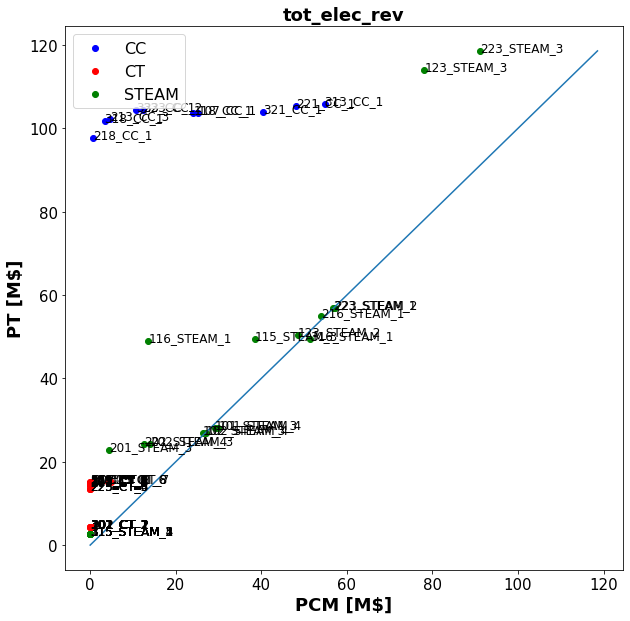

In [58]:
def make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item, marker="dot"):
    if item in ["tot_elec_rev", "tot_op_cost", "tot_profit"]:
        factor = 1e6
        unit = "M$"
    if item == "tot_dispatch":
        factor = 1e3
        unit = "GWh"
    if item == "num_startup":
        factor =1
        unit = "#"
    color = {"CC": "b", "CT": "r", "STEAM": "g"}
    fig, ax = plt.subplots(figsize=(10, 10))
    for f in gen_forms:
        item_pt = []
        item_pcm = []
        for name in gen_forms[f]:
            y = df_all_gen_summarize_PT[df_all_gen_summarize_PT.index==name][item]/factor
            x = df_all_gen_summarize_PCM[df_all_gen_summarize_PCM.index==name][item]/factor
            item_pt.append(y)
            item_pcm.append(x)
            
            if marker == "gen_name":
                ax.text(x, y, name, fontsize=12)
        if marker == "dot":
            ax.scatter(item_pcm, item_pt, c=color[f], label=f)
        
        if marker == "both":
            for x, y, name in zip(item_pcm, item_pt, gen_forms[f]):
                ax.text(x, y, name, fontsize=12)
            ax.scatter(item_pcm, item_pt, c=color[f], label=f)
        
    # plot y = x
    minimum = min(df_all_gen_summarize_PCM[item].min()/factor, df_all_gen_summarize_PT[item].min()/factor)
    maximum = max(df_all_gen_summarize_PCM[item].max()/factor, df_all_gen_summarize_PT[item].max()/factor)
    x = np.linspace(minimum, maximum)
    ax.plot(x,x)
    ax.set_xlabel(f"PCM [{unit}]", font=font1)
    ax.set_ylabel(f"PT [{unit}]", font=font1)
    ax.set_title(f"{item}", font=font1)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.legend(prop={"size": 16})
    
    return

make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item='tot_elec_rev', marker='both')

C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:830: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:831: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:690: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\tex

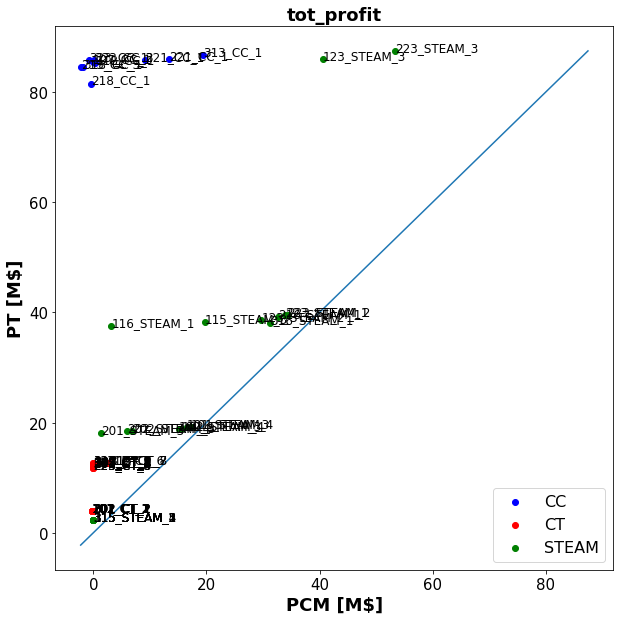

In [59]:
make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item='tot_profit', marker='both')

C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:830: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:831: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:690: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\tex

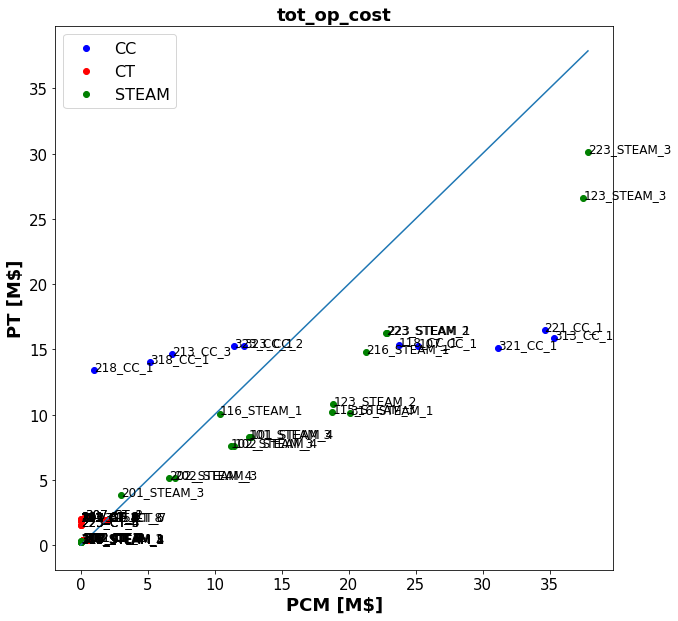

In [60]:
make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item="tot_op_cost", marker='both')

C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:830: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:831: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:690: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\tex

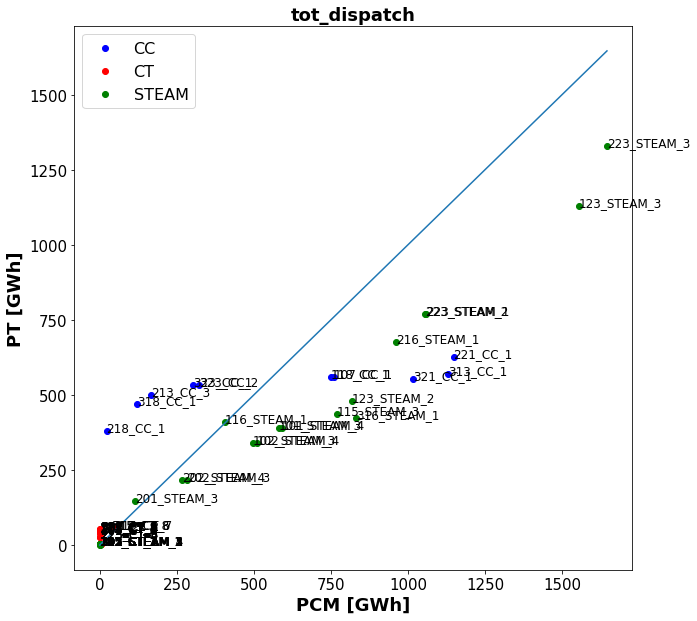

In [61]:
make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item="tot_dispatch", marker='both')

C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:830: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  x = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:831: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  y = float(self.convert_yunits(self._y))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\text.py:690: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  posx = float(self.convert_xunits(self._x))
C:\Users\JKLCh\anaconda3\envs\tsa\lib\site-packages\matplotlib-3.5.1-py3.8-win-amd64.egg\matplotlib\tex

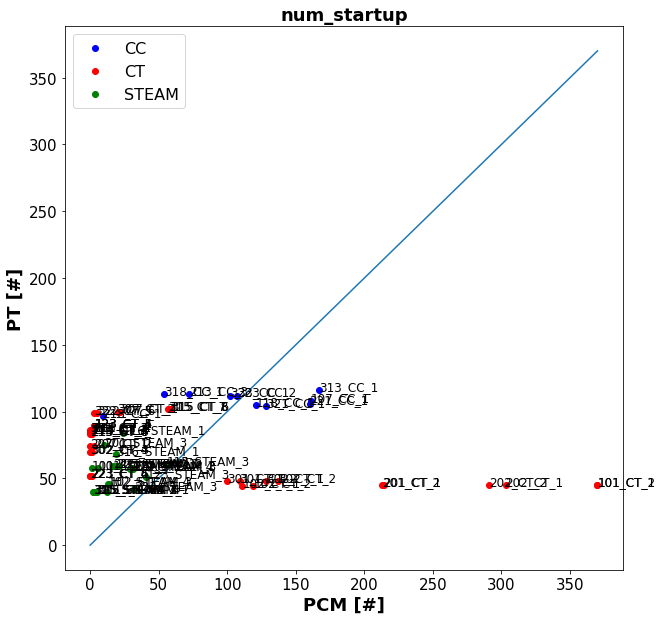

In [62]:
make_parity_plot(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, item="num_startup", marker='both')

## Detailed generator level analysis

In [67]:
def print_results(df_all_gen_summarize_PT, df_all_gen_summarize_PCM, item):
    print("Gen Name    ",  f"PT_{item}    ", f"PCM_{item}    ", "Rate %")
    for name in gen_dict["fossil"].keys():
        pt_res = np.round(df_all_gen_summarize_PT.loc[name][item], 2)
        pcm_res = np.round(df_all_gen_summarize_PCM.loc[name][item], 2)
        rate = 100 * (pt_res-pcm_res)/(pcm_res + 1) # avoid divided by 0
        print(name, "    ", pt_res, "    ",  pcm_res, "    ", rate)
    return

print_results(df_all_gen_summarize_PT, df_all_gen_summarize_PCM, item="tot_profit")

Gen Name     PT_tot_profit     PCM_tot_profit     Rate %
101_CT_1      4010516.65      -204954.32      -2056.795649858221
101_CT_2      4010516.65      -254613.64      -1675.144757149527
101_STEAM_3      19117329.97      16538620.89      15.592043261834304
101_STEAM_4      19117329.97      17263375.57      10.73923396435532
102_CT_1      3993201.54      -108660.81      -3774.9581468990236
102_CT_2      3993201.54      -94500.03      -4325.654527882455
102_STEAM_3      18859154.81      15166857.11      24.344512708044313
102_STEAM_4      18859154.81      15559980.85      21.202942212943512
107_CC_1      85438216.59      -108748.42      -78665.74214818155
113_CT_1      12340781.79      -7302.75      -169111.30263293046
113_CT_2      12340781.79      -8720.33      -141633.6131331192
113_CT_3      12340781.79      0.0      1234078179.0
113_CT_4      12340781.79      0.0      1234078179.0
115_STEAM_1      2299404.16      -12526.59      -18457.65947951354
115_STEAM_2      2299404.16      -44

### Calculate capacity factors

In [70]:
def calculate_cf(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, gen_dict, gen_name):
    pmax = gen_dict["fossil"][gen_name]["max_p"]
    pt_cf = df_all_gen_summarize_PT.loc[gen_name]["tot_dispatch"]/pmax/8784
    pcm_cf = df_all_gen_summarize_PCM.loc[gen_name]["tot_dispatch"]/pmax/8784
    
    return pt_cf, pcm_cf

pt_cf_dict = {}
pcm_cf_dict = {}
diff_cf_dict = {}    # (pt-pcm)/pcm
for name in gen_names:
    pt_cf, pcm_cf = calculate_cf(df_all_gen_summarize_PCM, df_all_gen_summarize_PT, gen_dict, gen_name=name)
    pt_cf_dict[name] = pt_cf
    pcm_cf_dict[name] = pcm_cf
    diff_cf_dict[name] = (pt_cf - pcm_cf)/(pcm_cf + 1e-6)

summarize_cf_dict = {"GO":[], "SO":[], "NO":[], "NU":[], "SU":[], "GU":[]}
for key, value in diff_cf_dict.items():
    if value > 1:
        summarize_cf_dict["GO"].append(key)
    if (0.2 < value) and (value <= 1):
        summarize_cf_dict["SO"].append(key)
    if (0.0 < value) and (value <= 0.2):
        summarize_cf_dict["NO"].append(key)
    if (-0.2 < value) and (value <= 0.0):
        summarize_cf_dict["NU"].append(key)
    if (-1.0 < value) and (value <= -0.2):
        summarize_cf_dict["SU"].append(key)
    if value <= -1:
        summarize_cf_dict["GU"].append(key)
    
# summarize_cf_dict

In [71]:
# check the level of overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["GO"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])

Gen name     Diff rate     PT CF     PCM CF     Fuel price
102_CT_1     2.3479     0.0186     0.0056     10.3494
102_CT_2     2.1663     0.0186     0.0059     10.3494
113_CT_1     624.6522     0.1003     0.0002     3.88722
113_CT_2     728.1698     0.1003     0.0001     3.88722
113_CT_3     100341.5301     0.1003     0.0     3.88722
113_CT_4     100341.5301     0.1003     0.0     3.88722
115_STEAM_1     5.3089     0.0177     0.0028     10.3494
115_STEAM_2     21.0802     0.0177     0.0008     10.3494
123_CT_1     148.3365     0.1021     0.0007     3.88722
123_CT_4     134.6693     0.1021     0.0008     3.88722
123_CT_5     113.8916     0.1021     0.0009     3.88722
207_CT_1     91734.9727     0.0917     0.0     3.88722
207_CT_2     222.2909     0.0917     0.0004     3.88722
213_CC_3     2.0112     0.1605     0.0533     3.88722
213_CT_1     364.5823     0.1003     0.0003     3.88722
213_CT_2     273.4369     0.1003     0.0004     3.88722
215_CT_4     97085.6102     0.0971     0.0     3.

In [72]:
# check the level of overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["SO"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])


Gen name     Diff rate     PT CF     PCM CF     Fuel price
201_CT_1     0.7229     0.0193     0.0112     10.3494
201_CT_2     0.7772     0.0193     0.0108     10.3494
201_STEAM_3     0.2945     0.2217     0.1713     2.11399
315_CT_6     0.3664     0.1162     0.085     3.88722
315_CT_7     0.2136     0.1162     0.0957     3.88722
315_CT_8     0.5076     0.1162     0.0771     3.88722
323_CC_1     0.7617     0.1713     0.0972     3.88722
323_CC_2     0.6515     0.1713     0.1037     3.88722


In [73]:
# check the level of overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["NO"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])


Gen name     Diff rate     PT CF     PCM CF     Fuel price
116_STEAM_1     0.0071     0.3003     0.2982     2.11399
202_CT_1     0.1676     0.0198     0.017     10.3494
202_CT_2     0.1931     0.0198     0.0166     10.3494


In [35]:
# check the level of overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["NU"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])


Gen name     Diff rate     PT CF     PCM CF     Fuel price
116_STEAM_1     -0.0222     0.3003     0.3072     2.11399
202_CT_1     -0.1689     0.0198     0.0239     10.3494
202_CT_2     -0.1783     0.0198     0.0241     10.3494
323_CC_1     -0.0542     0.1713     0.1811     3.88722
323_CC_2     -0.0949     0.1713     0.1893     3.88722


In [34]:
# check the level of under/overestimation
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in summarize_cf_dict["SU"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])


Gen name     Diff rate     PT CF     PCM CF     Fuel price
101_CT_1     -0.4099     0.0189     0.032     10.3494
101_CT_2     -0.4254     0.0189     0.0328     10.3494
101_STEAM_3     -0.3112     0.5839     0.8477     2.11399
101_STEAM_4     -0.3051     0.5839     0.8402     2.11399
102_STEAM_3     -0.2954     0.5083     0.7214     2.11399
102_STEAM_4     -0.2865     0.5083     0.7125     2.11399
107_CC_1     -0.3151     0.1799     0.2627     3.88722
115_STEAM_3     -0.4189     0.3199     0.5504     2.11399
118_CC_1     -0.3358     0.1798     0.2708     3.88722
123_STEAM_2     -0.3906     0.353     0.5793     2.11399
123_STEAM_3     -0.2506     0.3671     0.4899     2.11399
202_STEAM_3     -0.2886     0.3249     0.4568     2.11399
202_STEAM_4     -0.2394     0.3249     0.4272     2.11399
216_STEAM_1     -0.2471     0.4975     0.6609     2.11399
221_CC_1     -0.4463     0.2003     0.3618     3.88722
223_STEAM_1     -0.2322     0.5641     0.7347     2.11399
223_STEAM_2     -0.2317     0.

In [46]:
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in gen_forms["CC"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}")

Gen name     Diff rate     PT CF     PCM CF
107_CC_1     -0.3151     0.1799     0.2627
118_CC_1     -0.3358     0.1798     0.2708
213_CC_3     0.8368     0.1605     0.0874
218_CC_1     1.6178     0.1216     0.0464
221_CC_1     -0.4463     0.2003     0.3618
313_CC_1     -0.4618     0.1827     0.3396
318_CC_1     1.8151     0.1507     0.0535
321_CC_1     -0.4167     0.1778     0.3048
323_CC_1     -0.0542     0.1713     0.1811
323_CC_2     -0.0949     0.1713     0.1893


In [39]:
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in gen_forms["CT"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])

Gen name     Diff rate     PT CF     PCM CF     Fuel price
101_CT_1     -0.4099     0.0189     0.032     10.3494
101_CT_2     -0.4254     0.0189     0.0328     10.3494
102_CT_1     1.6186     0.0186     0.0071     10.3494
102_CT_2     1.321     0.0186     0.008     10.3494
113_CT_1     33.4193     0.1003     0.0029     3.88722
113_CT_2     33.6902     0.1003     0.0029     3.88722
113_CT_3     27.986     0.1003     0.0035     3.88722
113_CT_4     22.3127     0.1003     0.0043     3.88722
123_CT_1     7.3449     0.1021     0.0122     3.88722
123_CT_4     7.1009     0.1021     0.0126     3.88722
123_CT_5     7.1332     0.1021     0.0126     3.88722
201_CT_1     0.1044     0.0193     0.0174     10.3494
201_CT_2     0.1073     0.0193     0.0174     10.3494
202_CT_1     -0.1689     0.0198     0.0239     10.3494
202_CT_2     -0.1783     0.0198     0.0241     10.3494
207_CT_1     12.9896     0.0917     0.0066     3.88722
207_CT_2     12.9896     0.0917     0.0066     3.88722
213_CT_1     25.1

In [40]:
print("Gen name    ", "Diff rate    ", "PT CF    ", "PCM CF    ", "Fuel price")
for gen in gen_forms["STEAM"]:
    print(f"{gen}    ", f"{np.round(diff_cf_dict[gen], 4)}    ", f"{np.round(pt_cf_dict[gen], 4)}    ", f"{np.round(pcm_cf_dict[gen],4)}    ", gen_dict["fossil"][gen]["fuel_p"])

Gen name     Diff rate     PT CF     PCM CF     Fuel price
101_STEAM_3     -0.3112     0.5839     0.8477     2.11399
101_STEAM_4     -0.3051     0.5839     0.8402     2.11399
102_STEAM_3     -0.2954     0.5083     0.7214     2.11399
102_STEAM_4     -0.2865     0.5083     0.7125     2.11399
115_STEAM_1     8.34     0.0177     0.0019     10.3494
115_STEAM_2     8.9893     0.0177     0.0018     10.3494
115_STEAM_3     -0.4189     0.3199     0.5504     2.11399
116_STEAM_1     -0.0222     0.3003     0.3072     2.11399
123_STEAM_2     -0.3906     0.353     0.5793     2.11399
123_STEAM_3     -0.2506     0.3671     0.4899     2.11399
201_STEAM_3     0.0305     0.2217     0.2152     2.11399
202_STEAM_3     -0.2886     0.3249     0.4568     2.11399
202_STEAM_4     -0.2394     0.3249     0.4272     2.11399
216_STEAM_1     -0.2471     0.4975     0.6609     2.11399
223_STEAM_1     -0.2322     0.5641     0.7347     2.11399
223_STEAM_2     -0.2317     0.5641     0.7342     2.11399
223_STEAM_3     -0.

In [20]:
# No dispatch
df_all_gen_summarize_PCM[df_all_gen_summarize_PCM["tot_elec_rev"]==0]

,tot_elec_rev,tot_dispatch,tot_op_cost,tot_profit,num_startup
223_CT_5,0.0,0.0,0.0,0.0,0
223_CT_6,0.0,0.0,0.0,0.0,0


In [21]:
df_all_gen_summarize_PCM.loc["322_CT_6"], df_all_gen_summarize_PT.loc["322_CT_6"]

(tot_elec_rev    341288.447985
 tot_dispatch      9844.542912
 tot_op_cost     768252.317417
 tot_profit     -426963.869432
 num_startup         65.000000
 Name: 322_CT_6, dtype: float64,
 tot_dispatch        5.328400e+04
 tot_elec_rev        1.507211e+07
 tot_op_cost         1.925696e+06
 tot_startup_cost    5.608582e+05
 tot_profit          1.258556e+07
 num_startup         9.900000e+01
 Name: 322_CT_6, dtype: float64)

## Check the marginal cost of generators

In [7]:
for name in gen_dict["fossil"].keys():
    print(name, "    ", gen_dict["fossil"][name]["fuel_p"])


101_CT_1      10.3494
101_CT_2      10.3494
101_STEAM_3      2.11399
101_STEAM_4      2.11399
102_CT_1      10.3494
102_CT_2      10.3494
102_STEAM_3      2.11399
102_STEAM_4      2.11399
107_CC_1      3.88722
113_CT_1      3.88722
113_CT_2      3.88722
113_CT_3      3.88722
113_CT_4      3.88722
115_STEAM_1      10.3494
115_STEAM_2      10.3494
115_STEAM_3      2.11399
116_STEAM_1      2.11399
118_CC_1      3.88722
123_STEAM_2      2.11399
123_STEAM_3      2.11399
123_CT_1      3.88722
123_CT_4      3.88722
123_CT_5      3.88722
201_CT_1      10.3494
201_CT_2      10.3494
201_STEAM_3      2.11399
202_CT_1      10.3494
202_CT_2      10.3494
202_STEAM_3      2.11399
202_STEAM_4      2.11399
207_CT_1      3.88722
207_CT_2      3.88722
213_CC_3      3.88722
213_CT_1      3.88722
213_CT_2      3.88722
215_CT_4      3.88722
215_CT_5      3.88722
216_STEAM_1      2.11399
218_CC_1      3.88722
221_CC_1      3.88722
223_STEAM_1      2.11399
223_STEAM_2      2.11399
223_STEAM_3      2.11399
223